### 2.1) PV Simulation 

This notebook converts irradiance into hourly AC PV output using a simplified pvlib/PVWatts pipeline.

Two scenarios are simulated:

- Scenario A: actual irradiance
- Scenario B: forecast irradiance

The PV system is represented as a 100 kW AC system with a DC/AC ratio of 1.2.

### 2.2) Import

In [58]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from src.config import SiteConfig, PVConfig
from src.pv_model import pv_ac_power_series

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 2.3) Load Inputs

In [59]:
df = pd.read_csv("../data/processed/phase2_inputs.csv")
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

if df["time"].dt.tz is not None:
    df["time"] = df["time"].dt.tz_localize(None)

# Physical guardrails
df["ghi_actual_wh_m2"] = df["ghi_actual_wh_m2"].clip(lower=0)
df["ghi_forecast_wh_m2"] = df["ghi_forecast_wh_m2"].clip(lower=0)

site = SiteConfig()
pv = PVConfig()

df.head()

,time,ghi_actual_wh_m2,ghi_forecast_wh_m2,temp_c,load_kw
0,2025-01-01 00:00:00,0.0,0.000000,20.26,20.182830
1,2025-01-01 01:00:00,0.0,0.000000,19.19,19.426256
2,2025-01-01 02:00:00,0.0,0.000000,18.34,20.758769
3,2025-01-01 03:00:00,0.0,31.248153,17.54,21.819825
4,2025-01-01 04:00:00,0.0,70.391975,16.76,22.388684


### 2.4) Simulate PV for both Scenarios

In [60]:
pv_actual = pv_ac_power_series(
    df=df,
    ghi_col="ghi_actual_wh_m2",
    temp_col="temp_c",
    site=site,
    pv=pv
)

pv_forecast = pv_ac_power_series(
    df=df,
    ghi_col="ghi_forecast_wh_m2",
    temp_col="temp_c",
    site=site,
    pv=pv
)

### 2.5) Save Outputs

In [61]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame({"pv_actual_kw": pv_actual.values}).to_csv(
    output_dir / "pv_actual_kw.csv", index=False
)
pd.DataFrame({"pv_forecast_kw": pv_forecast.values}).to_csv(
    output_dir / "pv_forecast_kw.csv", index=False
)

print("Saved PV outputs.")

Saved PV outputs.


### 2.6) Build combined PV dataframe

In [62]:
pv_df = pd.DataFrame({
    "time": df["time"],
    "pv_actual_kw": pv_actual.values,
    "pv_forecast_kw": pv_forecast.values
})

pv_df.head()

,time,pv_actual_kw,pv_forecast_kw
0,2025-01-01 00:00:00,0.0,0.0
1,2025-01-01 01:00:00,0.0,0.0
2,2025-01-01 02:00:00,0.0,0.0
3,2025-01-01 03:00:00,0.0,0.0
4,2025-01-01 04:00:00,0.0,0.0


### 2.7) Sanity Check Plot (2 weeks)

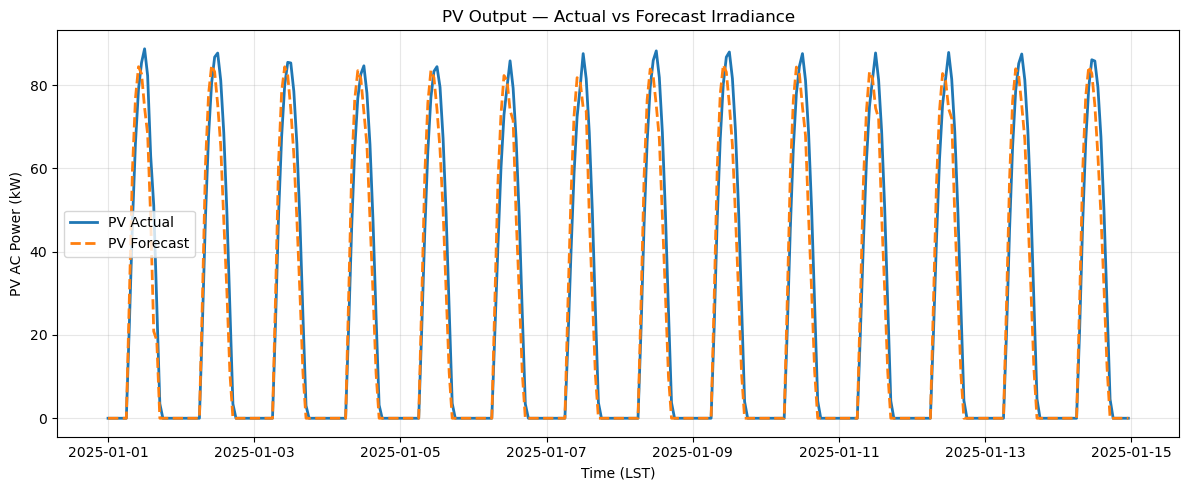

In [63]:
pv_plot = pv_df[(pv_df["time"] >= "2025-01-01") & (pv_df["time"] < "2025-01-15")].copy()

plt.figure(figsize=(12, 5))
plt.plot(pv_plot["time"], pv_plot["pv_actual_kw"], label="PV Actual", linewidth=2)
plt.plot(pv_plot["time"], pv_plot["pv_forecast_kw"], label="PV Forecast", linestyle="--", linewidth=2)
plt.xlabel("Time (LST)")
plt.ylabel("PV AC Power (kW)")
plt.title("PV Output — Actual vs Forecast Irradiance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.8) Daily Sanity Check Around Noon / Night

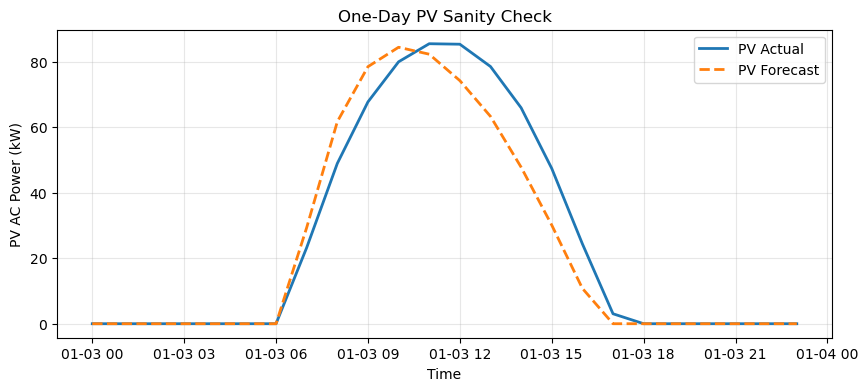

In [64]:
sample_day = pv_df[(pv_df["time"] >= "2025-01-03") & (pv_df["time"] < "2025-01-04")]

plt.figure(figsize=(10, 4))
plt.plot(sample_day["time"], sample_day["pv_actual_kw"], label="PV Actual", linewidth=2)
plt.plot(sample_day["time"], sample_day["pv_forecast_kw"], label="PV Forecast", linestyle="--", linewidth=2)
plt.xlabel("Time")
plt.ylabel("PV AC Power (kW)")
plt.title("One-Day PV Sanity Check")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 2.8) Sanity Interpretation (PV Output Sanity Check)

- near-zero production at night is physically correct

- peak mismatch comes from upstream irradiance forecast bias/timing

- afternoon under/over-shoot reflects the baseline forecast limitations, not inverter physics

These deviations are expected from a baseline forecasting model and are important
because they propagate into battery charging behavior and evening supply adequacy
in the mini-grid simulation.